In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [3]:
v0_10MW = np.load("./rotor_coefficients/shapiro/v0_10MW_rotor_coefficients.npy")
v0_15MW = np.load("./rotor_coefficients/shapiro/v0_15MW_rotor_coefficients.npy")
v0_22MW = np.load("./rotor_coefficients/shapiro/v0_22MW_rotor_coefficients.npy")

avgs_10MW = np.load("./rotor_coefficients/shapiro/v0_10MW_rotor_averages.npy")

v2_10MW = np.load("./rotor_coefficients/shapiro/v2_10MW_rotor_coefficients.npy")
v2_15MW = np.load("./rotor_coefficients/shapiro/v2_15MW_rotor_coefficients.npy")
v2_22MW = np.load("./rotor_coefficients/shapiro/v2_22MW_rotor_coefficients.npy")

avgs_15MW = np.load("./rotor_coefficients/shapiro/v0_15MW_rotor_averages.npy")

v4_10MW = np.load("./rotor_coefficients/shapiro/v4_10MW_rotor_coefficients.npy")
v4_15MW = np.load("./rotor_coefficients/shapiro/v4_15MW_rotor_coefficients.npy")
v4_22MW = np.load("./rotor_coefficients/shapiro/v4_22MW_rotor_coefficients.npy")

avgs_22MW = np.load("./rotor_coefficients/shapiro/v0_22MW_rotor_averages.npy")

In [4]:
def madsen_func(CT, a, b, c):

    # k1 = 0.0883
    # k2 = 0.0586
    # k3 = 0.2460

    return a * CT**3 + b * CT**2 + c * CT

In [5]:
# Generate fitted values
x = np.linspace(0, 2, 100)
v0_10MW_fit = madsen_func(x, v0_10MW[0], v0_10MW[1], v0_10MW[2])
v2_10MW_fit = madsen_func(x, v2_10MW[0], v2_10MW[1], v2_10MW[2])
v4_10MW_fit = madsen_func(x, v4_10MW[0], v4_10MW[1], v4_10MW[2])

v0_15MW_fit = madsen_func(x, v0_15MW[0], v0_15MW[1], v0_15MW[2])
v2_15MW_fit = madsen_func(x, v2_15MW[0], v2_15MW[1], v2_15MW[2])
v4_15MW_fit = madsen_func(x, v4_15MW[0], v4_15MW[1], v4_15MW[2])

v0_22MW_fit = madsen_func(x, v0_22MW[0], v0_22MW[1], v0_22MW[2])
v2_22MW_fit = madsen_func(x, v2_22MW[0], v2_22MW[1], v2_22MW[2])
v4_22MW_fit = madsen_func(x, v4_22MW[0], v4_22MW[1], v4_22MW[2])

In [6]:
v4 = [0,12]
v2 = [1, 2, 3, 9, 10, 11]
v0 = [4, 5, 6, 7, 8]

/tmp/ipykernel_144498/1907970821.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v4], avgs_10MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=1)
/tmp/ipykernel_144498/1907970821.py:43: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v2], avgs_10MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=1)
/tmp/ipykernel_144498/1907970821.py:44: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v0], avgs_10MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=1)
/tmp/ipykernel_144498/1907970821.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_15MW[0][v4], avgs_15MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.5)
/tmp/ipykernel_144498/1907970821.py:47: UserWarnin

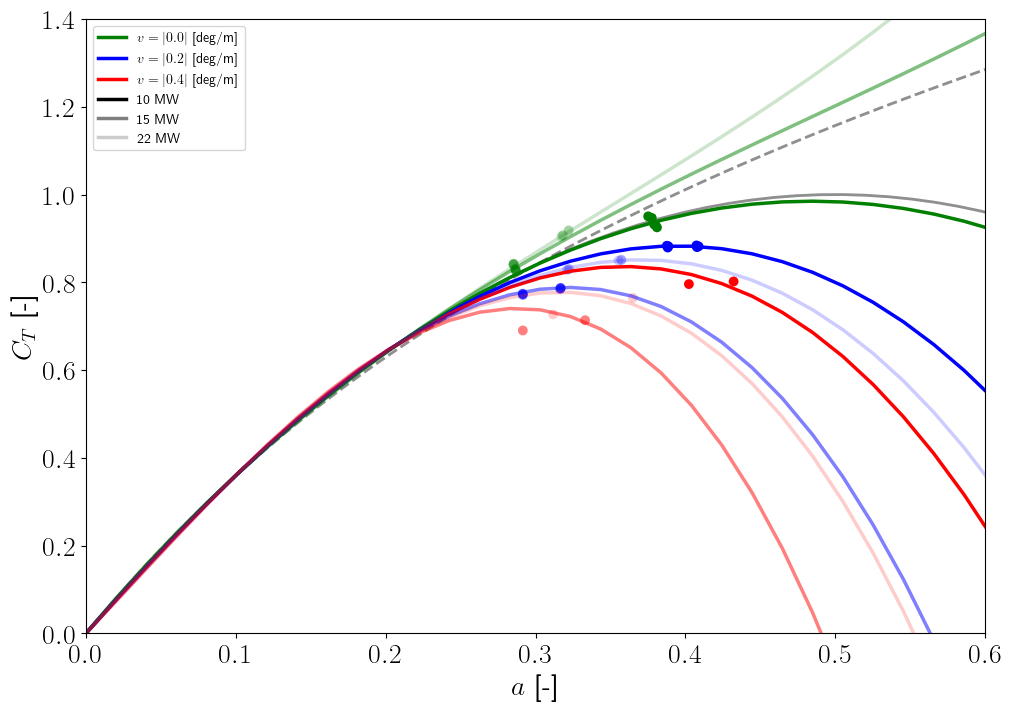

In [7]:
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)
ax.plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)
ax.plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)

ax.plot(x, v0_10MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.0|$ [deg/m]')
ax.plot(x, v2_10MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.2|$ [deg/m]')
ax.plot(x, v4_10MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.4|$ [deg/m]')

ax.plot(x, v0_15MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=0.5,label='')
ax.plot(x, v2_15MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=0.5,label='')
ax.plot(x, v4_15MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=0.5,label='')

ax.plot(x, v0_22MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=0.2,label='')
ax.plot(x, v2_22MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=0.2,label='')
ax.plot(x, v4_22MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=0.2,label='')

ax.plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=1,label='10 MW')
ax.plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=0.5,label='15 MW')
ax.plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=0.2,label='22 MW')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.4])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

v4 = [0,12]
v2 = [1, 2, 3, 9, 10, 11]
v0 = [4, 5, 6, 7, 8]

ax.scatter(avgs_10MW[0][v4], avgs_10MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=1)
ax.scatter(avgs_10MW[0][v2], avgs_10MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=1)
ax.scatter(avgs_10MW[0][v0], avgs_10MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=1)

ax.scatter(avgs_15MW[0][v4], avgs_15MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.5)
ax.scatter(avgs_15MW[0][v2], avgs_15MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.5)
ax.scatter(avgs_15MW[0][v0], avgs_15MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.5)

ax.scatter(avgs_22MW[0][v4], avgs_22MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.2)
ax.scatter(avgs_22MW[0][v2], avgs_22MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.2)
ax.scatter(avgs_22MW[0][v0], avgs_22MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.2)

ax.legend()

# plt.savefig(f"./figs/Madsen_rotor_comparison_v1.png", bbox_inches="tight", dpi=600)

In [5]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']

NameError: name 'x' is not defined

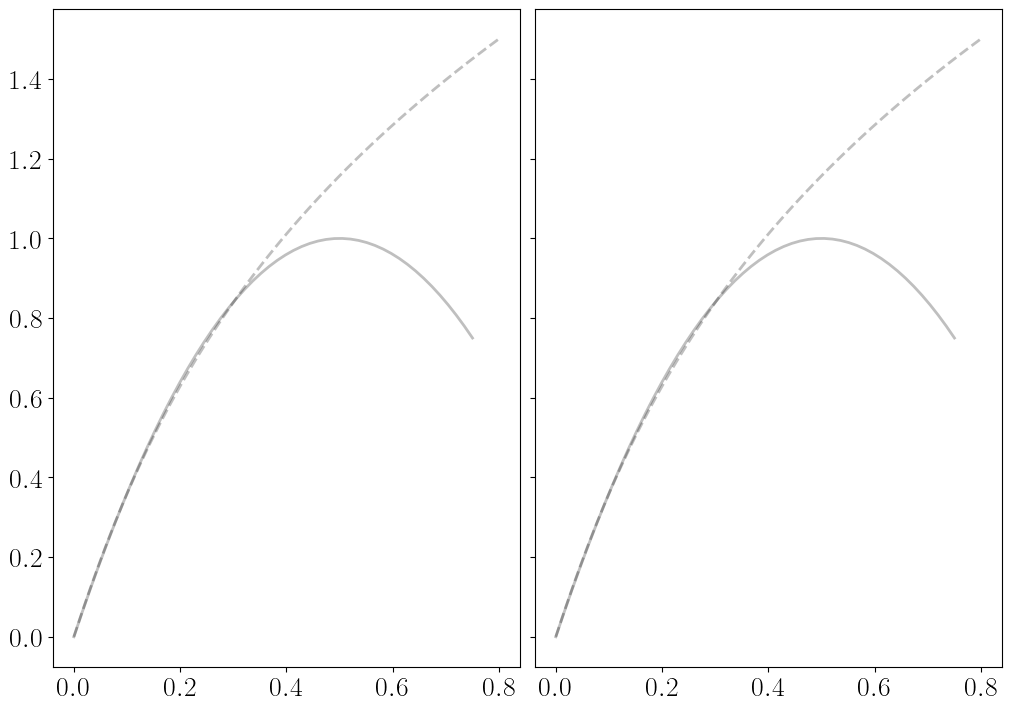

In [6]:
fig, ax = plt.subplots(1,2,figsize=(10, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax[0].plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)
ax[1].plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax[0].plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)
ax[1].plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)

ax[0].plot(x, v0_10MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.0|$ [deg/m]')
ax[0].plot(x, v2_10MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.2|$ [deg/m]')
ax[0].plot(x, v4_10MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.4|$ [deg/m]')

ax[0].plot(x, v0_15MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=0.5,label='')
ax[0].plot(x, v2_15MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=0.5,label='')
ax[0].plot(x, v4_15MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=0.5,label='')

ax[0].plot(x, v0_22MW_fit, 'g-',linewidth=2.5,zorder=2,alpha=0.2,label='')
ax[0].plot(x, v2_22MW_fit, 'b-',linewidth=2.5,zorder=2,alpha=0.2,label='')
ax[0].plot(x, v4_22MW_fit, 'r-',linewidth=2.5,zorder=2,alpha=0.2,label='')

ax[0].plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=1,label='10 MW')
ax[0].plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=0.5,label='15 MW')
ax[0].plot([-1,-1], [0,1], 'k-',linewidth=2.5,zorder=2,alpha=0.2,label='22 MW')

ax[0].set_xlim([0,0.6])
ax[0].set_ylim([0,1.5])

ax[0].set_ylabel('$C_T$ [-]', fontsize=20)
ax[0].set_xlabel('$a$ [-]', fontsize=20)
ax[1].set_xlabel('$a$ [-]', fontsize=20)

v4 = [0,12]
v2 = [1, 2, 3, 9, 10, 11]
v0 = [4, 5, 6, 7, 8]

ax[1].scatter(avgs_10MW[0][v4], avgs_10MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=1)
ax[1].scatter(avgs_10MW[0][v2], avgs_10MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=1)
ax[1].scatter(avgs_10MW[0][v0], avgs_10MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=1)

ax[1].scatter(avgs_15MW[0][v4], avgs_15MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.5)
ax[1].scatter(avgs_15MW[0][v2], avgs_15MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.5)
ax[1].scatter(avgs_15MW[0][v0], avgs_15MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.5)

ax[1].scatter(avgs_22MW[0][v4], avgs_22MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.2)
ax[1].scatter(avgs_22MW[0][v2], avgs_22MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.2)
ax[1].scatter(avgs_22MW[0][v0], avgs_22MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.2)

ax[0].legend()

plt.savefig(f"./figs/Madsen_rotor_comparison_v2.png", bbox_inches="tight", dpi=600)

In [13]:
# V4

a_mom = np.linspace(0,0.1,50)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, avgs_10MW[0][v4])
a_mom = np.append(a_mom, avgs_15MW[0][v4])
a_mom = np.append(a_mom, avgs_22MW[0][v4])

ct_mom = np.append(ct_mom, avgs_10MW[1][v4])
ct_mom = np.append(ct_mom, avgs_15MW[1][v4])
ct_mom = np.append(ct_mom, avgs_22MW[1][v4])

ct_mom_ht = np.linspace(1.4,2,2)
a_mom_ht  = 0.0883*ct_mom_ht**3 + 0.0586*ct_mom_ht**2 + 0.2460 * ct_mom_ht

# a_mom = np.append(a_mom, a_mom_ht)
# ct_mom = np.append(ct_mom, ct_mom_ht-0.15)

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v4, b_fit_v4, c_fit_v4 = params
print(f"Fitted parameters: a = {a_fit_v4:.3f}, b = {b_fit_v4:.3f}, c = {c_fit_v4:.3f},")
np.save("./rotor_coefficients/shapiro/v4_all_turbine_coefficients.npy", [a_fit_v4,b_fit_v4,c_fit_v4])

# Generate fitted values
y_fit_v4 = madsen_func(x, a_fit_v4, b_fit_v4, c_fit_v4)

Fitted parameters: a = 0.749, b = -0.330, c = 0.300,


In [14]:
# V2

a_mom = np.linspace(0,0.1,50)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, avgs_10MW[0][v2])
a_mom = np.append(a_mom, avgs_15MW[0][v2])
a_mom = np.append(a_mom, avgs_22MW[0][v2])

ct_mom = np.append(ct_mom, avgs_10MW[1][v2])
ct_mom = np.append(ct_mom, avgs_15MW[1][v2])
ct_mom = np.append(ct_mom, avgs_22MW[1][v2])

ct_mom_ht = np.linspace(1.4,2,2)
a_mom_ht  = 0.0883*ct_mom_ht**3 + 0.0586*ct_mom_ht**2 + 0.2460 * ct_mom_ht

# a_mom = np.append(a_mom, a_mom_ht)
# ct_mom = np.append(ct_mom, ct_mom_ht)

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v2, b_fit_v2, c_fit_v2 = params
print(f"Fitted parameters: a = {a_fit_v2:.3f}, b = {b_fit_v2:.3f}, c = {c_fit_v2:.3f},")
np.save("./rotor_coefficients/shapiro/v2_all_turbine_coefficients.npy", [a_fit_v2,b_fit_v2,c_fit_v2])

# Generate fitted values
y_fit_v2 = madsen_func(x, a_fit_v2, b_fit_v2, c_fit_v2)

Fitted parameters: a = 0.515, b = -0.304, c = 0.310,


In [15]:
# V0

a_mom = np.linspace(0,0.1,50)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, avgs_10MW[0][v0])
a_mom = np.append(a_mom, avgs_15MW[0][v0])
a_mom = np.append(a_mom, avgs_22MW[0][v0])

ct_mom = np.append(ct_mom, avgs_10MW[1][v0])
ct_mom = np.append(ct_mom, avgs_15MW[1][v0])
ct_mom = np.append(ct_mom, avgs_22MW[1][v0])

ct_mom_ht = np.linspace(1.4,2,2)
a_mom_ht  = 0.0883*ct_mom_ht**3 + 0.0586*ct_mom_ht**2 + 0.2460 * ct_mom_ht

# a_mom = np.append(a_mom, a_mom_ht)
# ct_mom = np.append(ct_mom, ct_mom_ht+0.025)

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v0, b_fit_v0, c_fit_v0 = params
print(f"Fitted parameters: a = {a_fit_v0:.3f}, b = {b_fit_v0:.3f}, c = {c_fit_v0:.3f},")
np.save("./rotor_coefficients/shapiro/v0_all_turbine_coefficients.npy", [a_fit_v0,b_fit_v0,c_fit_v0])

# Generate fitted values
y_fit_v0 = madsen_func(x, a_fit_v0, b_fit_v0, c_fit_v0)

Fitted parameters: a = 0.364, b = -0.264, c = 0.311,


/tmp/ipykernel_144498/3049058480.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v4], avgs_10MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=1)
/tmp/ipykernel_144498/3049058480.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v2], avgs_10MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=1)
/tmp/ipykernel_144498/3049058480.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_10MW[0][v0], avgs_10MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=1)
/tmp/ipykernel_144498/3049058480.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(avgs_15MW[0][v4], avgs_15MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.4)
/tmp/ipykernel_144498/3049058480.py:31: UserWarnin

Text(0.4, 0.15, '$a = 0.75C_T^3 + -0.33C_T^2 + 0.30C_T$')

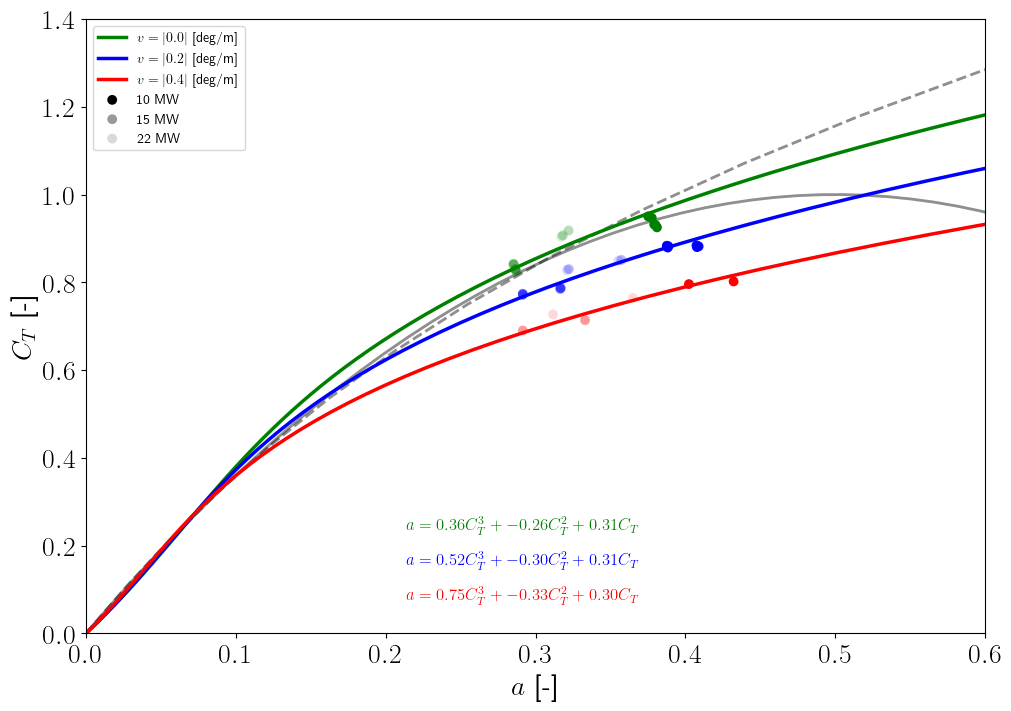

In [16]:
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)
ax.plot(a_mom, ct_mom, 'k',linewidth=2,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,15)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)
ax.plot(a_mad, ct_mad, 'k--',linewidth=2,zorder=2,alpha=0.25)

ax.plot(y_fit_v0, x, 'g-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.0|$ [deg/m]')
ax.plot(y_fit_v2, x, 'b-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.2|$ [deg/m]')
ax.plot(y_fit_v4, x, 'r-',linewidth=2.5,zorder=2,alpha=1,label='$v = |0.4|$ [deg/m]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.4])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

ax.scatter(avgs_10MW[0][v4], avgs_10MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=1)
ax.scatter(avgs_10MW[0][v2], avgs_10MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=1)
ax.scatter(avgs_10MW[0][v0], avgs_10MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=1)

ax.scatter(avgs_15MW[0][v4], avgs_15MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.4)
ax.scatter(avgs_15MW[0][v2], avgs_15MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.4)
ax.scatter(avgs_15MW[0][v0], avgs_15MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.4)

ax.scatter(avgs_22MW[0][v4], avgs_22MW[1][v4], cmap='viridis', s=50, edgecolor='none',color='r',alpha=0.15)
ax.scatter(avgs_22MW[0][v2], avgs_22MW[1][v2], cmap='viridis', s=50, edgecolor='none',color='b',alpha=0.15)
ax.scatter(avgs_22MW[0][v0], avgs_22MW[1][v0], cmap='viridis', s=50, edgecolor='none',color='g',alpha=0.15)

ax.scatter(-1,-1, cmap='viridis', s=50, edgecolor='none',color='k',alpha=1,label='10 MW')
ax.scatter(-1,-1, cmap='viridis', s=50, edgecolor='none',color='k',alpha=0.4,label='15 MW')
ax.scatter(-1,-1, cmap='viridis', s=50, edgecolor='none',color='k',alpha=0.15,label='22 MW')

ax.legend()

fig.text(0.4,0.25, f'$a = {a_fit_v0:0.2f}C_T^3 + {b_fit_v0:0.2f}C_T^2 + {c_fit_v0:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='green')
fig.text(0.4,0.20, f'$a = {a_fit_v2:0.2f}C_T^3 + {b_fit_v2:0.2f}C_T^2 + {c_fit_v2:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='blue')
fig.text(0.4,0.15, f'$a = {a_fit_v4:0.2f}C_T^3 + {b_fit_v4:0.2f}C_T^2 + {c_fit_v4:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='red')

# plt.savefig(f"./figs/wrf_all_turbines_rotor.png", bbox_inches="tight", dpi=600)

In [24]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']

# avgs_10MW = np.load("./rotor_coefficients/shapiro/v0_10MW_rotor_averages.npy")

# avgs_15MW = np.load("./rotor_coefficients/shapiro/v0_15MW_rotor_averages.npy")

# avgs_22MW = np.load("./rotor_coefficients/shapiro/v0_22MW_rotor_averages.npy")

avgs_10MW = np.load("./rotor_coefficients/noShapiro/v0_10MW_rotor_averages.npy")

avgs_15MW = np.load("./rotor_coefficients/noShapiro/v0_15MW_rotor_averages.npy")

avgs_22MW = np.load("./rotor_coefficients/noShapiro/v0_22MW_rotor_averages.npy")

/tmp/ipykernel_56014/1047763786.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(avgs_10MW[0][count], avgs_10MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[1],zorder=3)
/tmp/ipykernel_56014/1047763786.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(avgs_15MW[0][count], avgs_15MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[3],zorder=3)
/tmp/ipykernel_56014/1047763786.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(avgs_22MW[0][count], avgs_22MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[5],zorder=3)
/tmp/ipykernel_56014/1047763786.py:26: UserWarning: No data for colormapping provided via 'c'. Paramete

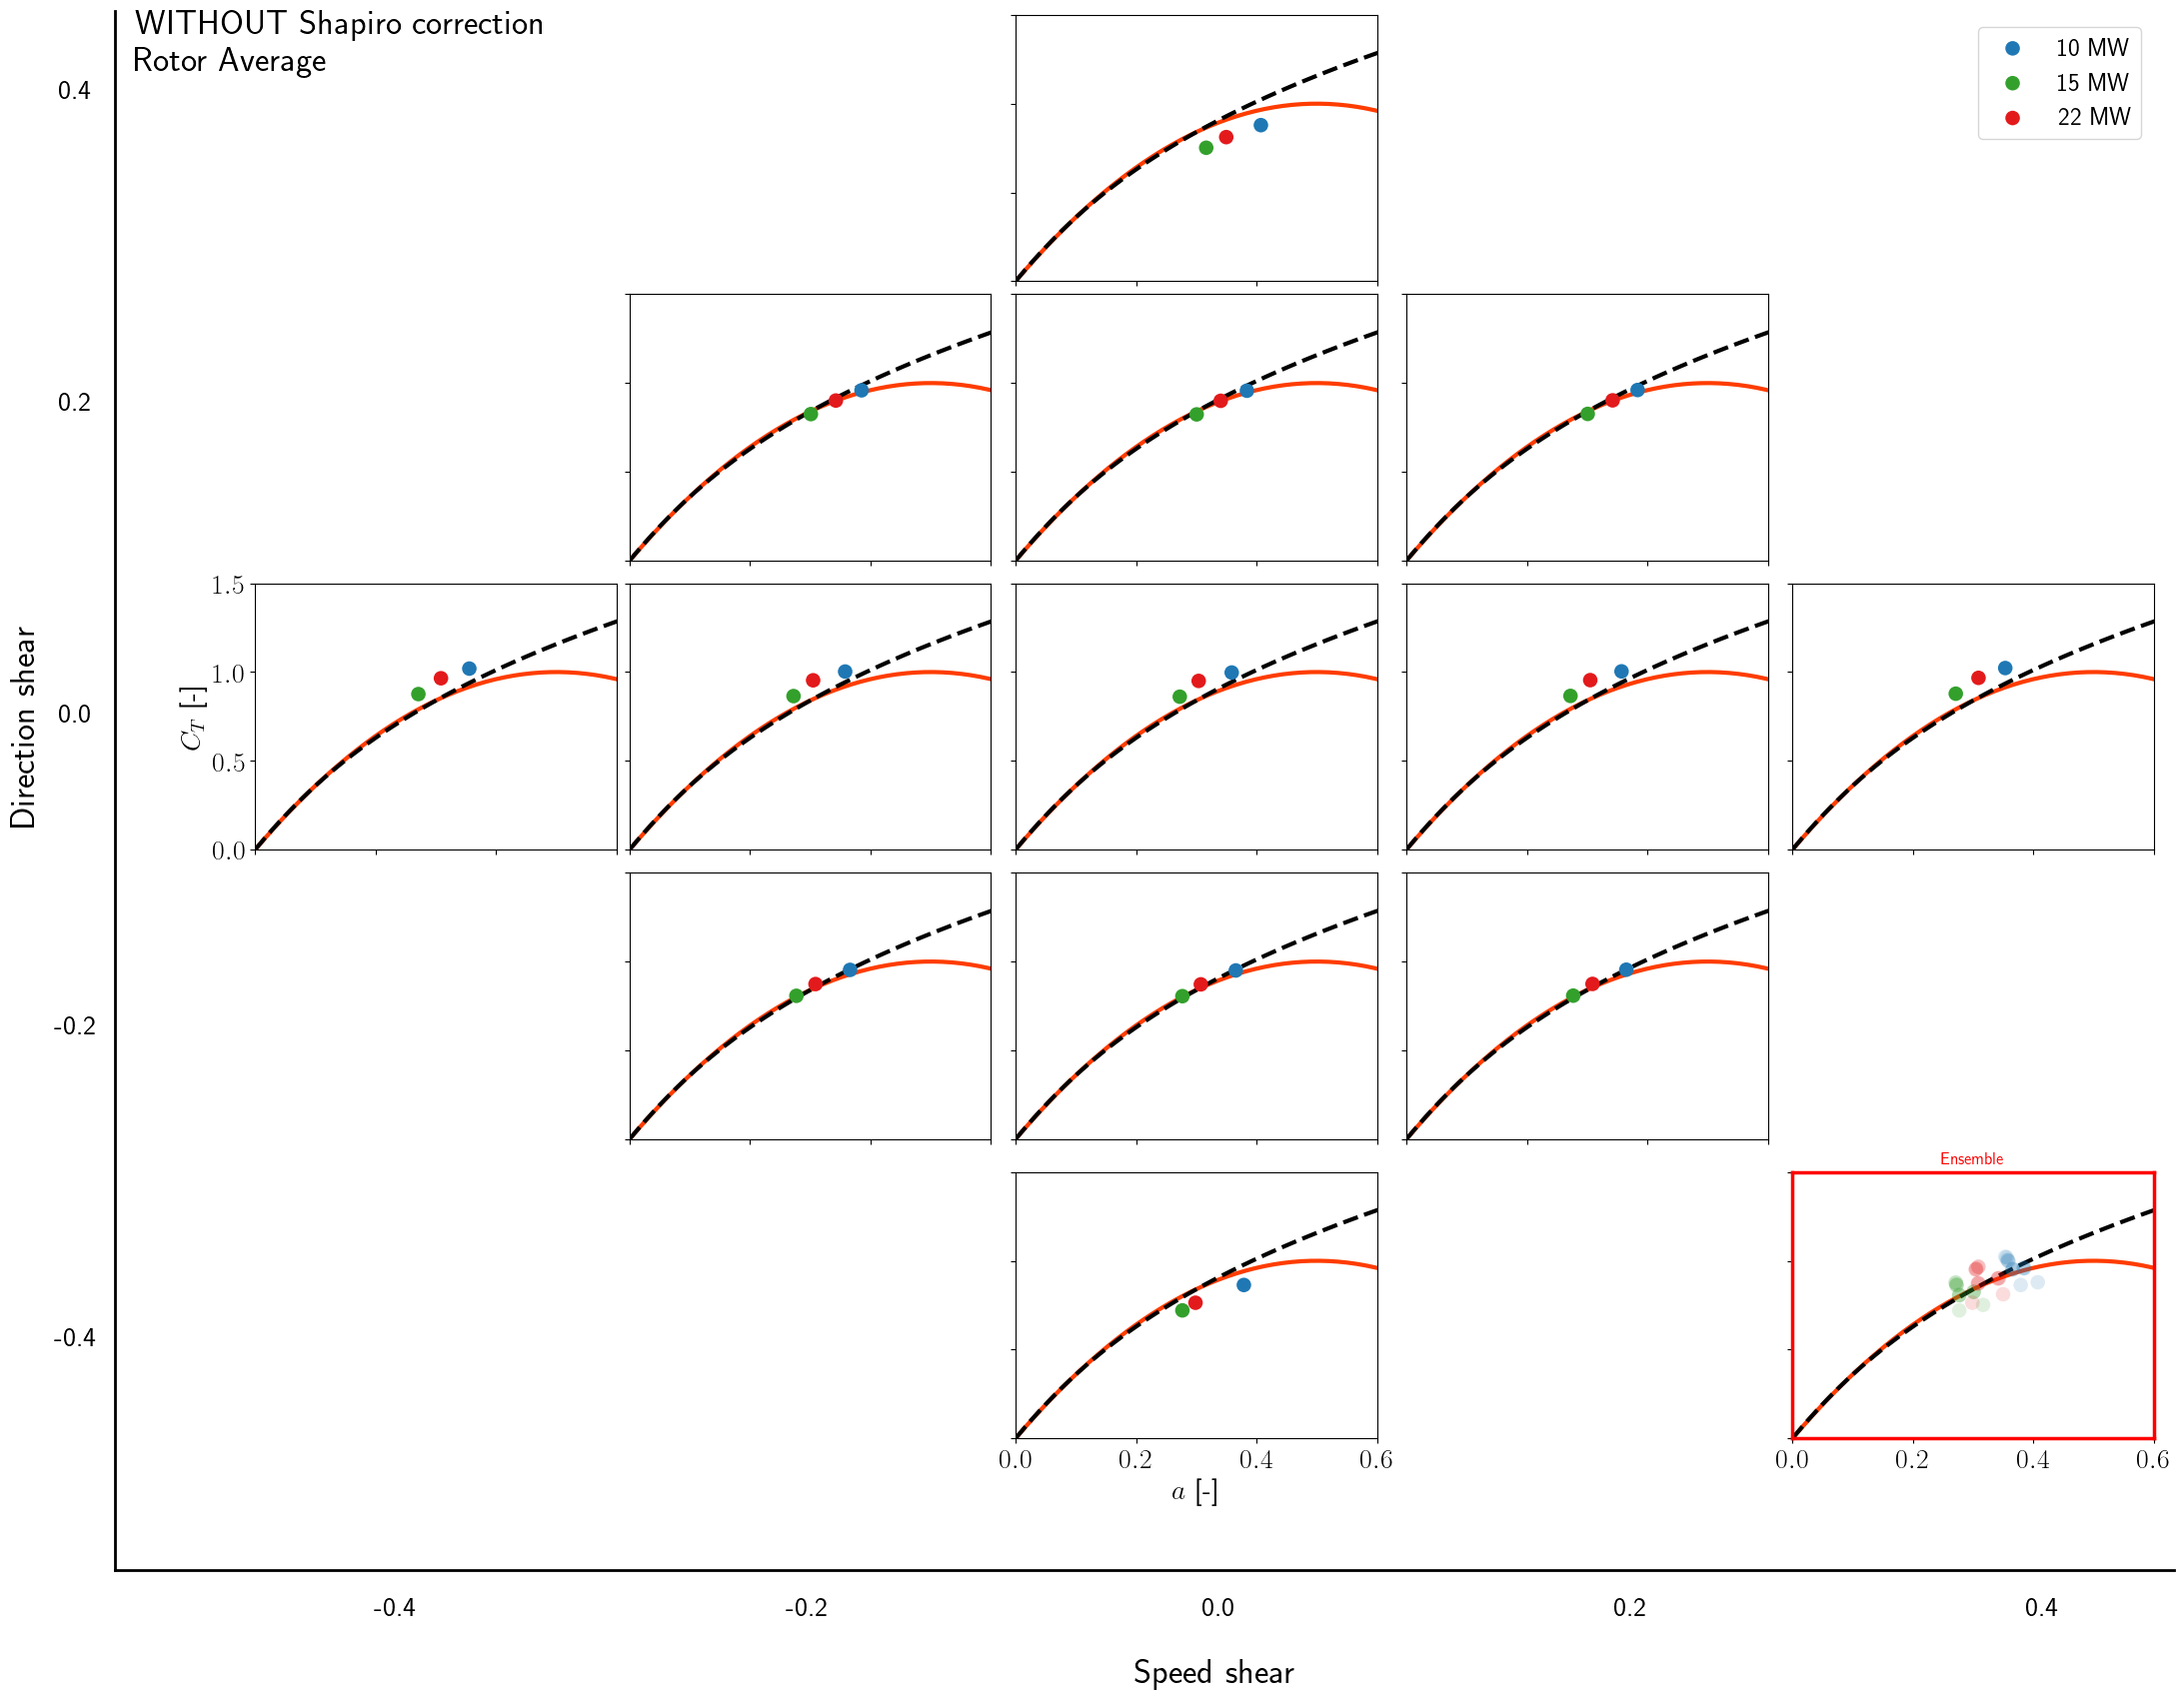

In [25]:
xs = [0,1,1,1,2,2,2,2,2,3,3,3,4]
ys = [2,1,2,3,0,1,2,3,4,1,2,3,2]

fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(20, 15), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):
    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

    ax[xs[count],ys[count]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)
    ax[xs[count],ys[count]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)
    mesh = ax[xs[count],ys[count]].scatter(avgs_10MW[0][count], avgs_10MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[1],zorder=3)
    mesh = ax[xs[count],ys[count]].scatter(avgs_15MW[0][count], avgs_15MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[3],zorder=3)
    mesh = ax[xs[count],ys[count]].scatter(avgs_22MW[0][count], avgs_22MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[5],zorder=3)


    ax[xs[count],ys[count]].set_xlim([0,0.6])
    ax[xs[count],ys[count]].set_ylim([0,1.5])

    ax[4,4].scatter(avgs_10MW[0][count], avgs_10MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[1],zorder=3,alpha=0.15)
    ax[4,4].scatter(avgs_15MW[0][count], avgs_15MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[3],zorder=3,alpha=0.15)
    ax[4,4].scatter(avgs_22MW[0][count], avgs_22MW[1][count], cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[5],zorder=3,alpha=0.15)


ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,3].axis('off')
ax[0,4].axis('off')

ax[1,0].axis('off')
ax[1,4].axis('off')

ax[3,0].axis('off')
ax[3,4].axis('off')

ax[4,0].axis('off')
ax[4,1].axis('off')
ax[4,3].axis('off')
# ax[4,4].axis('off')
for spine in ax[4,4].spines.values():
    spine.set_linewidth(2.5)
    spine.set_edgecolor('red')

ax[4,4].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)
ax[4,4].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)
ax[4,4].set_title('Ensemble', fontweight='bold',color='r')

ax[2,0].set_ylabel('$C_T$ [-]', fontsize=20)
ax[4,2].set_xlabel('$a$ [-]', fontsize=20)

# Add the number line below the subplots
line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 6)+0.14  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 6)+0.15  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear', ha='center', fontsize=25,rotation=90)
fig.text(-0.02,0.985, 'WITHOUT Shapiro correction', ha='left', fontsize=25,rotation=0)
fig.text(-0.02,0.96, 'Rotor Average', ha='left', fontsize=25,rotation=0)


ax[0,4].scatter(-100, -100, cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[1],zorder=3,alpha=1,label='10 MW')
ax[0,4].scatter(-100, -100, cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[3],zorder=3,alpha=1,label='15 MW')
ax[0,4].scatter(-100, -100, cmap='viridis', s=110, edgecolor='none',color=sns.color_palette("Paired")[5],zorder=3,alpha=1,label='22 MW')
ax[0,4].legend(loc="upper right",fontsize=18)

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()